<a href="https://colab.research.google.com/github/Bavesh-08/rainfall-prediction-using-ML/blob/main/rain_fall_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing the dependencies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.utils import resample
import pickle



In [ ]:
# data collection

data=pd.read_csv('/content/Rainfall.csv')
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [ ]:
# getting the datatype and shape opf the data

print(data.shape)
print(type(data))

(366, 12)
<class 'pandas.core.frame.DataFrame'>


In [ ]:
# getting some info about the data

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [ ]:
# getting futher info about the each column

data.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [ ]:
# checking is there is any null values

data.isnull().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [ ]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [ ]:
# handling the missing values

data["         winddirection"].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [ ]:
data["         winddirection"]=data["         winddirection"].fillna(data["         winddirection"].mode()[0])
data["windspeed"]=data["windspeed"].fillna(data["windspeed"].median())

In [ ]:
# checking is thgere any null values

data.isnull().sum()

,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0


In [ ]:
# converting the rainfall column

data["rainfall"]=data["rainfall"].map({"yes":1,"no":0})

In [ ]:
data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


EXPLOTARY DATA ANALYSIS

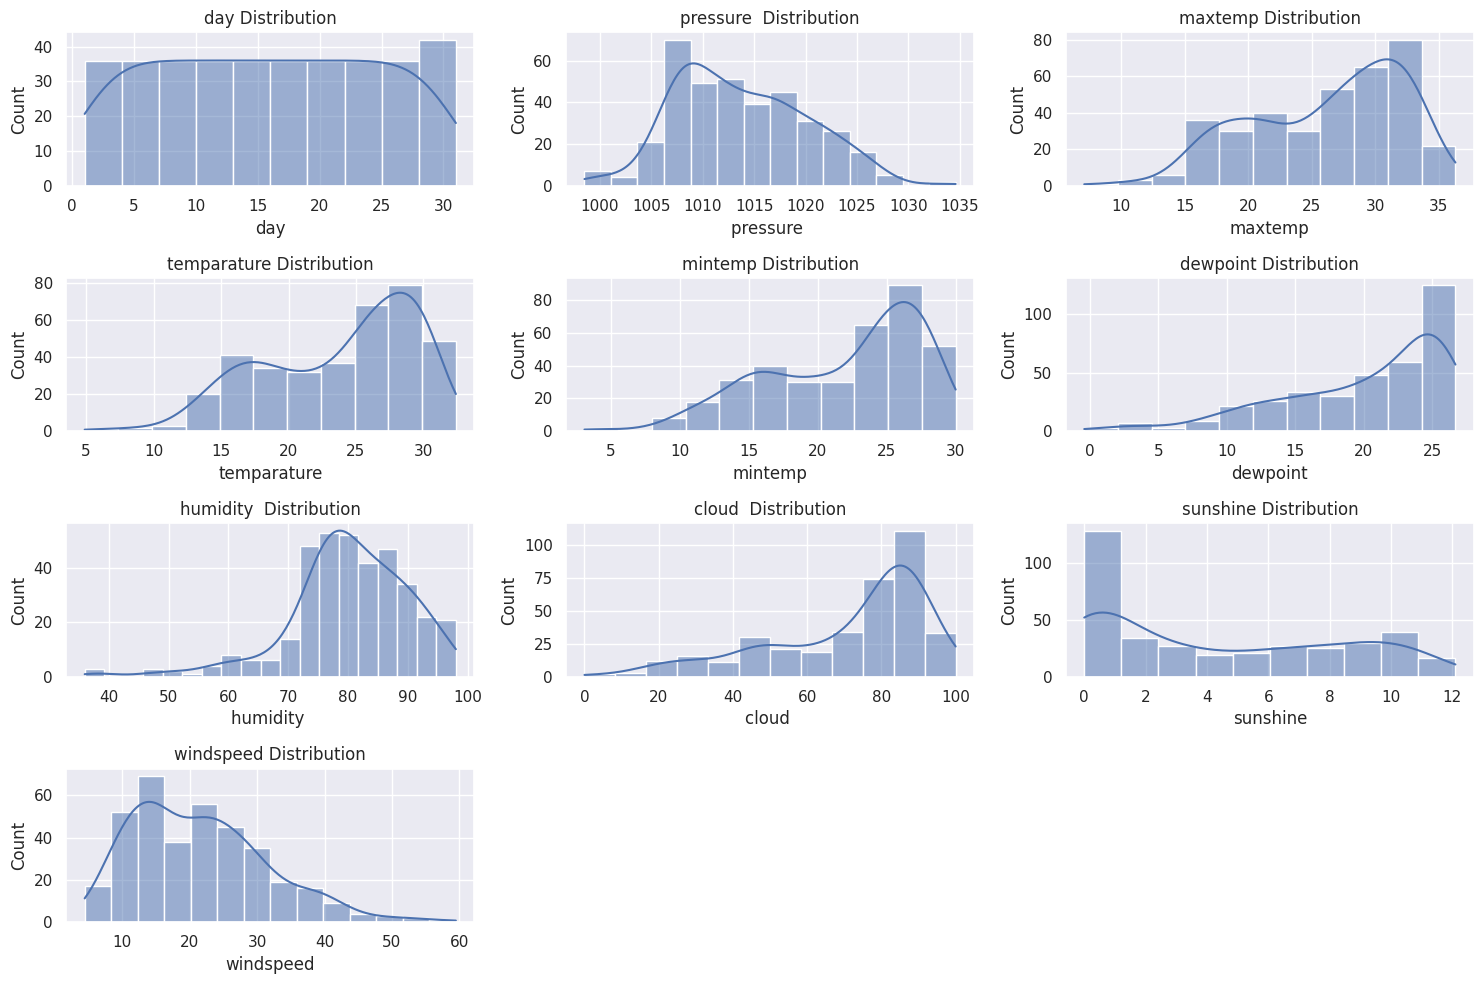

In [ ]:
# setting the style for all plot

sns.set(style="darkgrid")

plt.figure(figsize=(15,10)) # Increased figure size for better visualization

for i, column in enumerate(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint','humidity ', 'cloud ', 'sunshine','windspeed'],1):
  plt.subplot(4,3,i)
  sns.histplot(data[column], kde=True)
  plt.title(f"{column} Distribution")
  plt.tight_layout()
plt.show()

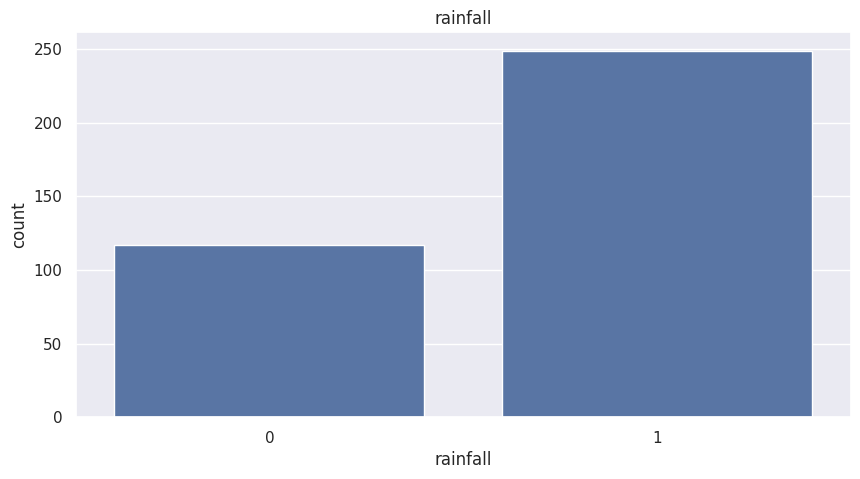

In [ ]:
# getting the distrubution of rainfall column

plt.figure(figsize=(10,5))
sns.countplot(x="rainfall",data=data)
plt.title("rainfall")
plt.show()

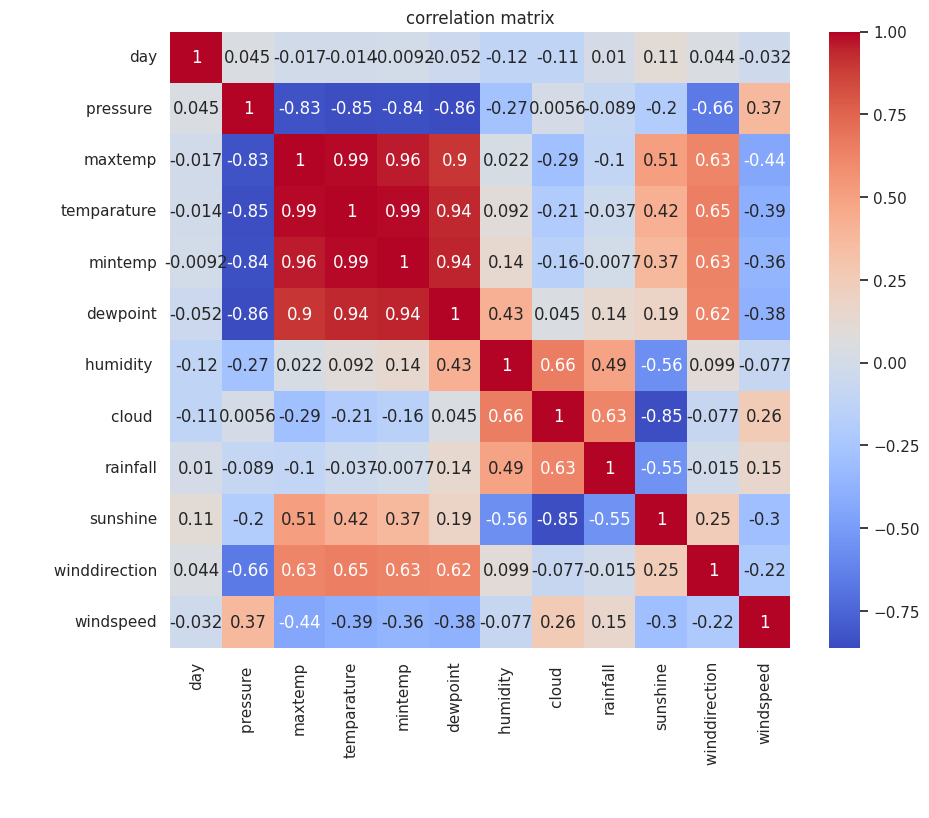

In [ ]:
# gettingb the coorelation matrix

plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

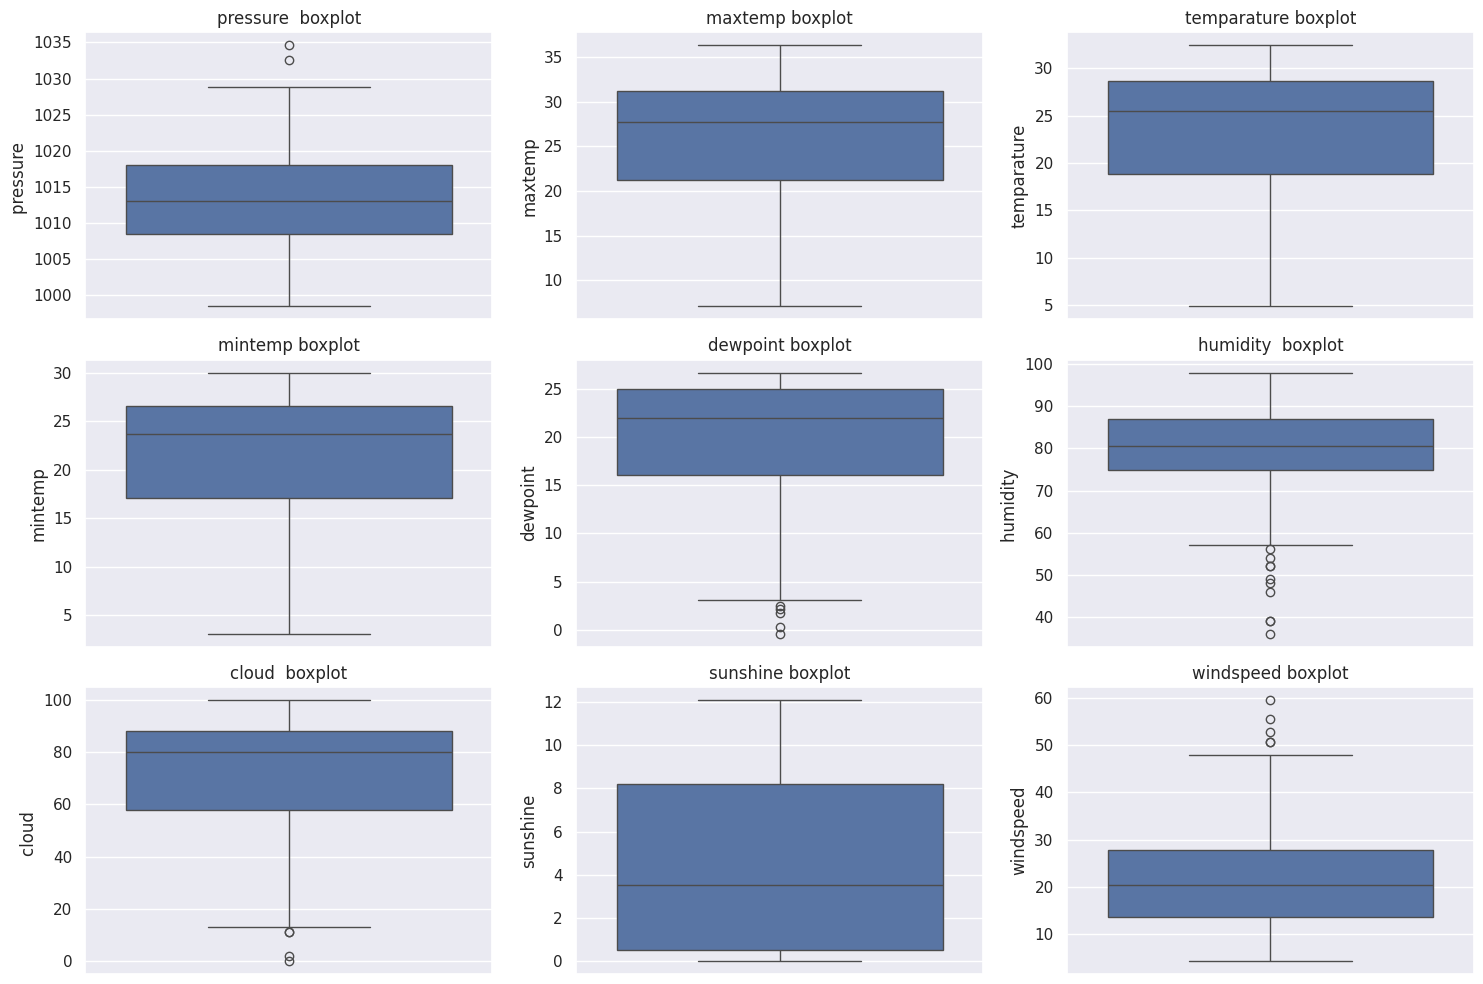

In [ ]:
plt.figure(figsize=(15,10))

for i, column in enumerate(['pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint','humidity ', 'cloud ', 'sunshine','windspeed'],1):
  plt.subplot(3,3,i)
  sns.boxplot(data[column])
  plt.title(f"{column} boxplot")
  plt.tight_layout()
plt.show()

In [ ]:
# droping the highly corelated column

data=data.drop(columns=['maxtemp', 'temparature', 'mintemp'])
data.head()

,day,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,2,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,3,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,4,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,5,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [ ]:
# getting the unique values inthe label

print(data['rainfall'].value_counts())

rainfall
1    249
0    117
Name: count, dtype: int64


In [ ]:
# seperating the majority and minority

df_minority=data[data['rainfall']==0]
df_majority=data[data['rainfall']==1]
print(df_majority.shape)
print(df_minority.shape)

(249, 9)
(117, 9)


In [ ]:
# down sampling the majority class to the minority class

df_majority_downsampled=resample(df_majority,replace=False,n_samples=len(df_minority),random_state=42)
print(df_majority_downsampled.shape)

(117, 9)


In [ ]:
# concat the downsampled class to the minority class

df_downsampled=pd.concat([df_majority_downsampled,df_minority])

In [ ]:
# suffleing the final dataframe

df_downsampled=df_downsampled.sample(frac=1,random_state=42).reset_index(drop=True)
df_downsampled.head()


,day,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,8,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,17,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,5,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,26,1007.6,24.8,85,84,1,1.8,70.0,34.8
4,5,1021.2,8.4,66,18,0,10.1,20.0,24.4


In [ ]:
# splitingf the features and target

x=df_downsampled.drop(columns=['rainfall'])
y=df_downsampled['rainfall']

In [ ]:
# spliting for training and spliting

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [ ]:
# building the model

rf_model=RandomForestClassifier(random_state=42)

param_grid_rf={

               "n_estimators":[50,100,200],
               "max_features":["auto","sqrt","log2"],
               "max_depth":[None,10,20,30],
               "min_samples_split":[2,5,10],
               "min_samples_leaf":[1,2,4]

}


In [ ]:
# hyperparameter tuning with gridsearch cv

grid_rf=GridSearchCV(estimator=rf_model,param_grid=param_grid_rf,cv=5,n_jobs=-1,verbose=2)
grid_rf.fit(x_train,y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
350 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [ ]:
# getting the best parameters

best_rf_model=grid_rf.best_estimator_
print(best_rf_model)

RandomForestClassifier(max_features='log2', min_samples_split=5,
                       n_estimators=50, random_state=42)


In [ ]:
# model evulation using cross validation

cv_scores_rf=cross_val_score(best_rf_model,x_train,y_train,cv=5)
print(cv_scores_rf)
print(np.mean(cv_scores_rf))

[0.71052632 0.89473684 0.81081081 0.81081081 0.89189189]
0.82375533428165


In [ ]:
# test set perfomance

y_pred_rf=best_rf_model.predict(x_test)
print(classification_report(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))
print(accuracy_score(y_test,y_pred_rf))


              precision    recall  f1-score   support

           0       0.76      0.67      0.71        24
           1       0.69      0.78      0.73        23

    accuracy                           0.72        47
   macro avg       0.73      0.72      0.72        47
weighted avg       0.73      0.72      0.72        47

[[16  8]
 [ 5 18]]
0.723404255319149
